In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [34]:
import sys
import os
import pandas as pd
import numpy as np
from os.path import join as pjoin

from catrace.stats import sort_conditions, pool_training_conditions
from catrace.visualize import plot_measure, plot_all_measures

dataset_name = 'simulation'
config_file = f'../dataset_configs/{dataset_name}_dataset_rand_both_t7.json'

In [35]:


def rename_odor_index_levels(df_per_fish):
    df_per_fish.reset_index(level=['odor_0', 'odor_1'], inplace=True)
    # Rename columns odor_0 to odor1 and odor_1 to odor2
    df_per_fish.rename(columns={'odor_0': 'odor1', 'odor_1': 'odor2'}, inplace=True)
    # Set odor1 and odor2 as index
    df_per_fish.set_index(['odor1', 'odor2'], inplace=True, append=True)
    return df_per_fish

if 'odor_0' in df_result.index.names:
    df_per_fish_juv = df_result.xs(False, level='shuffle').groupby(['fish_id', 'condition', 'odor_0', 'odor_1'], sort=False).mean()
    df_per_fish_juv_shuffled = df_result.xs(True, level='shuffle').groupby(['fish_id', 'condition', 'odor_0', 'odor_1'], sort=False).mean()

    df_per_fish_juv = rename_odor_index_levels(df_per_fish_juv)
    df_per_fish_juv_shuffled = rename_odor_index_levels(df_per_fish_juv_shuffled)
else:
    df_per_fish_juv = df_result.xs(False, level='shuffle').groupby(['fish_id', 'condition', 'odor1', 'odor2'], sort=False).mean()
    df_per_fish_juv_shuffled = df_result.xs(True, level='shuffle').groupby(['fish_id', 'condition', 'odor1', 'odor2'], sort=False).mean()

juv_conditions =  ['naive', 'arg-phe', 'phe-arg', 'phe-trp']
cond_mapping = {'naive': 'naive', 'both_n':'trained'}
conditions_pooled = ['naive', 'trained']

df_pooled = pool_training_conditions(df_per_fish_juv, cond_mapping)

df_pooled_shuffled = pool_training_conditions(df_per_fish_juv_shuffled, cond_mapping)


In [36]:
df_pooled

capacity  dimension    radius   utility  \
fish_id   odor1 odor2 condition                                            
rand_A1   aa1   ba2   naive      0.067574  23.903438  1.117571  0.896601   
                ba3   naive      0.066536  24.231652  1.126072  0.901002   
          aa3   ba1   naive      0.069501  23.642119  1.100547  0.899756   
          aa2   aa3   naive      0.065672  24.162574  1.129292  0.888998   
          ba1   ba2   naive      0.053779  27.805879  1.246758  0.909617   
...                                   ...        ...       ...       ...   
both_n_D2 aa3   ba2   trained    0.070844  23.061658  1.092317  0.888467   
                ba3   trained    0.071996  22.682577  1.088912  0.885465   
          aa1   ba1   trained    0.072862  22.462345  1.091462  0.888998   
          aa2   ba1   trained    0.078275  20.378570  1.092925  0.867732   
          aa1   aa3   trained    0.074242  21.489886  1.090091  0.865947   

                                 center_alignment  axis_alignment  \
fish_id   odor1 odor2 condition                                     
rand_A1   aa1   ba2   naive              0.426950        0.042053   
                ba3   naive              0.452902        0.040979   
          aa3   ba1   naive              0.353027        0.037459   
          aa2   aa3   naive              0.568087        0.056180   
          ba1   ba2   naive              0.601474        0.048568   
...                                           ...             ...   
both_n_D2 aa3   ba2   trained            0.416789        0.041285   
                ba3   trained            0.410644        0.043437   
          aa1   ba1   trained            0.399252        0.042288   
          aa2   ba1   trained            0.374175        0.045781   
          aa1   aa3   trained            0.570018        0.067412   

                                 center_axis_alignment  additional_info  \
fish_id   odor1 odor2 condition                                           
rand_A1   aa1   ba2   naive                   0.174440              NaN   
                ba3   naive                   0.169731              NaN   
          aa3   ba1   naive                   0.166913              NaN   
          aa2   aa3   naive                   0.200551              NaN   
          ba1   ba2   naive                   0.166203              NaN   
...                                                ...              ...   
both_n_D2 aa3   ba2   trained                 0.180727              NaN   
                ba3   trained                 0.185650              NaN   
          aa1   ba1   trained                 0.185060              NaN   
          aa2   ba1   trained                 0.214256              NaN   
          aa1   aa3   trained                 0.236198              NaN   

                                 capacity_geometric_approx  \
fish_id   odor1 odor2 condition                              
rand_A1   aa1   ba2   naive                       0.075373   
                ba3   naive                       0.073856   
          aa3   ba1   naive                       0.077257   
          aa2   aa3   naive                       0.073881   
          ba1   ba2   naive                       0.059128   
...                                                    ...   
both_n_D2 aa3   ba2   trained                     0.079745   
                ba3   trained                     0.081314   
          aa1   ba1   trained                     0.081971   
          aa2   ba1   trained                     0.090235   
          aa1   aa3   trained                     0.085742   

                                 capacity_effective_approx  ...  \
fish_id   odor1 odor2 condition                             ...   
rand_A1   aa1   ba2   naive                       0.067574  ...   
                ba3   naive                       0.066536  ...   
          aa3   ba1   naive                       0.069501  ...   
          aa2   aa3   naive 

[('aa1', 'aa3'), ('aa1', 'ba1'), ('aa3', 'ba3'), ('aa1', 'ba3'), ('ba1', 'ba2'), ('ba1', 'ba3'), ('ba2', 'ba3'), ('aa2', 'aa3'), ('aa2', 'ba1'), ('aa2', 'ba2'), ('aa1', 'aa2'), ('aa2', 'ba3'), ('aa3', 'ba1'), ('aa3', 'ba2'), ('aa1', 'ba2')]
[('aa1', 'aa3'), ('aa1', 'ba1'), ('aa3', 'ba3'), ('aa1', 'ba3'), ('ba1', 'ba2'), ('ba1', 'ba3'), ('ba2', 'ba3'), ('aa2', 'aa3'), ('aa2', 'ba1'), ('aa2', 'ba2'), ('aa1', 'aa2'), ('aa2', 'ba3'), ('aa3', 'ba1'), ('aa3', 'ba2'), ('aa1', 'ba2')]
[('aa1', 'aa3'), ('aa1', 'ba1'), ('aa3', 'ba3'), ('aa1', 'ba3'), ('ba1', 'ba2'), ('ba1', 'ba3'), ('ba2', 'ba3'), ('aa2', 'aa3'), ('aa2', 'ba1'), ('aa2', 'ba2'), ('aa1', 'aa2'), ('aa2', 'ba3'), ('aa3', 'ba1'), ('aa3', 'ba2'), ('aa1', 'ba2')]
[('aa1', 'aa3'), ('aa1', 'ba1'), ('aa3', 'ba3'), ('aa1', 'ba3'), ('ba1', 'ba2'), ('ba1', 'ba3'), ('ba2', 'ba3'), ('aa2', 'aa3'), ('aa2', 'ba1'), ('aa2', 'ba2'), ('aa1', 'aa2'), ('aa2', 'ba3'), ('aa3', 'ba1'), ('aa3', 'ba2'), ('aa1', 'ba2')]
[('aa1', 'aa3'), ('aa1', 'ba1'), ('a

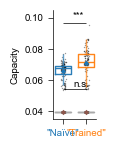

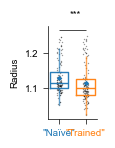

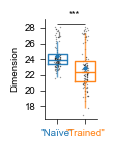

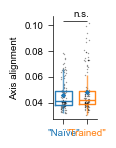

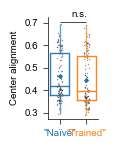

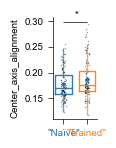

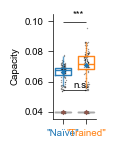

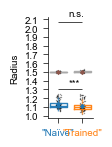

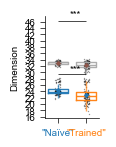

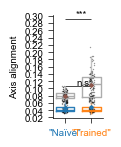

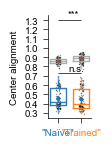

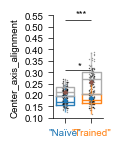

In [37]:
from catrace.for_paper import save_figure_for_paper, save_stats_json
from catrace.capacity_utils import plot_cap_and_save
from catrace.visualize import PlotBoxplotParams


plot_measure_params = PlotBoxplotParams(
    figsize=(1.2, 1.55),
    y_tick_label_fontsize=7,
    x_tick_label_fontsize=6,
    box_linewidth=1,
    box_width=0.7,
    mean_marker_size=0.7,
    strip_size=1.0,
    pvalue_bar_linewidth=0.5,
    box_colors=['tab:blue', 'tab:orange'],
    do_capitalize_labels=True,
    mean_marker_color='tab:blue',
    ylevel_scale = 1.08
)

capacity_ylim = (0.035, 0.105)
#tick_intervals = [0.02, 0.1, 5, 0.02, 0.2, 0.05]
tick_intervals = [0.02, 0.1, 2, 0.02, 0.1, 0.05]
juv_pooled_conditions = ['naive', 'trained']

vsname = 'all_vs_all'
odor1_group = ['aa1', 'aa2', 'aa3', 'ba1', 'ba2', 'ba3']
odor2_group = ['aa1', 'aa2', 'aa3', 'ba1', 'ba2', 'ba3']
xtick_labels = ['"Naïve"', '"Trained"']

test_results_dict = plot_cap_and_save(vsname, odor1_group, odor2_group,
                    df_pooled,
                    df_pooled_shuffled,
                    juv_pooled_conditions,
                    dataset_name,
                    fig_dir,
                    plot_measure_params,
                    tick_intervals,
                    capacity_ylim=capacity_ylim,
                    capacity_ylevel_scale=1.045,
                    do_save=True,
                    xtick_labels=xtick_labels)


test_results_dict = plot_cap_and_save(vsname, odor1_group, odor2_group,
                    df_pooled,
                    df_pooled_shuffled,
                    juv_pooled_conditions,
                    dataset_name,
                    fig_dir,
                    plot_measure_params,
                    tick_intervals,
                    capacity_ylim=capacity_ylim,
                    do_save=True,
                    do_plot_shuffled_measure=True,
                    xtick_labels=xtick_labels)

In [38]:
from catrace.stats import format_test_results_pair


def format_capacity_test_results_dict(test_results_dict):
    for measure_name, test_results in test_results_dict.items():
        print(measure_name)

        print(format_test_results_pair(test_results['raw']))
        if 'shuffled' in test_results:
            print('shuffled')
            print(format_test_results_pair(test_results['shuffled']))

format_capacity_test_results_dict(test_results_dict)

capacity
Comparing naive (mean = 0.0661 ± 0.00540, n = 120) vs trained (mean = 0.0713 ± 0.00875, n = 120): Mann–Whitney U test, U = 3757.00, P = 1.5 × 10^-10.
shuffled
Comparing naive (mean = 0.0397 ± 0.000109, n = 120) vs trained (mean = 0.0397 ± 0.000110, n = 120): Mann–Whitney U test, U = 6540.00, P = 0.220.
radius
Comparing naive (mean = 1.13 ± 0.0460, n = 120) vs trained (mean = 1.11 ± 0.0528, n = 120): Mann–Whitney U test, U = 9217.00, P = 0.0002.
shuffled
Comparing naive (mean = 1.50 ± 0.00488, n = 120) vs trained (mean = 1.50 ± 0.00701, n = 120): Mann–Whitney U test, U = 6306.00, P = 0.097.
dimension
Comparing naive (mean = 24.37 ± 1.52, n = 120) vs trained (mean = 22.85 ± 2.51, n = 120): Mann–Whitney U test, U = 10799.00, P = 2.2 × 10^-11.
shuffled
Comparing naive (mean = 33.03 ± 0.52, n = 120) vs trained (mean = 32.36 ± 1.04, n = 120): Mann–Whitney U test, U = 9881.00, P = 6.2 × 10^-7.
axis_alignment
Comparing naive (mean = 0.0458 ± 0.0112, n = 120) vs trained (mean = 0.0483 

In [39]:
measure_names = [
    'capacity',
    'radius',
    'dimension',
    'axis_alignment',
    'center_alignment',
    'center_axis_alignment',
]

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure08')
os.makedirs(save_dir, exist_ok=True)
df_pooled[measure_names].to_csv(os.path.join(save_dir, f'extended_figure08_simulation_capacity_and_geometric_measures.csv'))
df_pooled_shuffled[measure_names].to_csv(os.path.join(save_dir, f'extended_figure08_simulation_capacity_and_geometric_measures_shuffled.csv'))